# DP multi-component workflow (test)

Mirrors `dp_workflow.ipynb` but drives the refactored `src/DP_new.py`.
Key API changes vs. the old two-component `DP`:

- `fit_all` returns **`(dp_parent, dp_components, model_cube)`** instead of L/R arrays.
- `dp_parent`: one scalar row per galaxy (Z, mass, chosen `N_COMP`, BIC/chi2 per N, total flux per line).
- `dp_components`: **tidy/long** table, one row per (target, component, line).
- `bpt_classification` / `estimate_SFR` / `select_dp_sample` consume `dp_components`.
- `plot_fit` overlays every component for a target.

In [1]:
from src.misc import *
from src.SPECTRUM import Spectrum
from src.FITSPECTRUM import FitSpectrum
from src.DP_new import DP
import matplotlib.pyplot as plt
import numpy as np

In [2]:
spectra_data    = fits.open('/Users/hyp0515/data/0715_Spring_BGS_ALL_trimmed.fits')
cigale_data     = fits.open('/Users/hyp0515/data/IronPhysProp_v1.2_extracted.fits')
fastspecfit     = fits.open('/Users/hyp0515/data/0715_Spring_half_BGS_BRIGHT_catalog_fastspecfit.fits')

In [3]:
# new-schema output catalogs (parent + components + model cube live in one FITS each)
filenames = {
    'all' : './catalogs/test_all_multicomp.fits',
    'dps' : './catalogs/test_dps_multicomp.fits',
}

## Build the sample: keep sources with >=1 significant emission line (>5 S/N)

In [4]:
FIT = FitSpectrum()
DP  = DP()

ALL_SPECTRA = Spectrum(spectra_data, cigale_data, fastspecfit, load_targetID=None, subtype_filter='QSO')
print('Total number of spectra:', len(ALL_SPECTRA.targetID))

Data loading and processing took 45.91 seconds.
Total number of spectra: 99812


In [5]:
ALL_SPECTRA = FIT.label_emission_lines(ALL_SPECTRA, 5)
ALL_SPECTRA = FIT.significant_emission_filter(ALL_SPECTRA)
print('After significant-emission filter:', len(ALL_SPECTRA.targetID))

After significant-emission filter: 57271


In [6]:
# --- TEST MODE: thin the sample so a full 1..4-component fit runs quickly ---
# Comment this out for a production run.
ALL_SPECTRA = ALL_SPECTRA.shrink_dataset(3)
print('After shrinking:', len(ALL_SPECTRA.targetID))

After shrinking: 19091


In [7]:
ALL_SPECTRA.df.head()

,TARGETID,RA,DEC,Z,SPECTYPE,LOGM,LOGSFR,OII,Hbeta,OIII,Halpha,NII,SII
0,39627739380056197,177.003822,-1.903397,0.224113,GALAXY,10.250155,-0.348563,False,False,False,True,False,False
1,39627739380056768,177.028143,-1.960056,0.102814,GALAXY,10.143390,0.193251,True,False,False,True,True,True
2,39627739380057506,177.058476,-1.984356,0.102379,GALAXY,10.324258,-0.880754,False,False,False,True,True,False
3,39627739380058101,177.082610,-1.934162,0.155560,GALAXY,10.225356,0.697434,True,True,False,True,True,True
4,39627739380059797,177.158055,-1.894803,0.191538,GALAXY,10.211300,0.980484,True,True,True,True,True,True


## Fit everything
For each target, `fit_dp` fits N = 1..4 velocity components, picks N by minimum BIC,
and emits a scalar parent row + tidy per-(component, line) rows + the best-fit model.

In [8]:
dp_parent, dp_components, model_cube = DP.fit_all(data_class=ALL_SPECTRA, n_jobs=10)
print('parent    :', dp_parent.shape)
print('components:', dp_components.shape)
print('model cube:', model_cube.shape)
print('N_COMP distribution:')
print(dp_parent['N_COMP'].value_counts().sort_index())

100%|██████████| 19091/19091 [23:41<00:00, 13.43it/s]


parent    : (19091, 26)
components: (246040, 14)
model cube: (19091, 7781)
N_COMP distribution:
N_COMP
1    14155
2     4470
3      355
4      111
Name: count, dtype: int64


In [9]:
dp_parent[dp_parent['N_COMP']==1].head(50)

,TARGETID,RA,DEC,Z,LOGM,LOGSFR,N_COMP,N_COMP_FIT,BIC_1,CHISQ_1,...,OII3726_FLUX_TOT,OII3729_FLUX_TOT,Hbeta_FLUX_TOT,OIII4959_FLUX_TOT,OIII5007_FLUX_TOT,NII6548_FLUX_TOT,NII6583_FLUX_TOT,Halpha_FLUX_TOT,SII6716_FLUX_TOT,SII6731_FLUX_TOT
0,39627739380056197,177.003815,-1.903397,0.224113,10.250154,-0.348563,1,1,806.934814,746.551025,...,2.187608e+00,2.911692e+00,2.333906e+00,3.702966e-01,1.121627e+00,1.915406,5.873581,13.886660,1.245276,2.031616e+00
1,39627739380056768,177.028137,-1.960056,0.102814,10.143390,0.193251,1,1,778.497437,719.049805,...,9.052511e+00,1.204883e+01,1.082508e+01,2.856144e+00,8.651252e+00,5.784799,17.739046,57.278687,12.524423,9.734612e+00
2,39627739380057506,177.058472,-1.984356,0.102379,10.324259,-0.880754,1,1,932.511597,872.991150,...,3.795895e+00,5.052311e+00,1.424405e+01,2.527433e+00,7.655586e+00,11.554962,35.433216,52.574745,11.432298,8.916404e+00
3,39627739380058101,177.082611,-1.934162,0.155560,10.225355,0.697434,1,1,792.479126,732.580139,...,1.120853e+01,1.491848e+01,1.333870e+01,1.583678e+00,4.796955e+00,7.666858,23.510368,73.279938,16.087414,1.167860e+01
5,39627739380060386,177.186203,-1.910908,0.103712,9.617160,-4.524798,1,1,913.089172,853.556641,...,3.866423e+00,5.146183e+00,6.106123e+00,1.063767e+00,3.222146e+00,3.209318,9.841353,36.497776,8.800822,6.832327e+00
6,39627739380062010,177.248581,-1.948161,0.123900,10.082528,0.143419,1,1,835.185425,775.533081,...,9.390339e+00,1.249848e+01,8.081827e+00,4.531208e-01,1.372502e+00,6.552620,20.093567,49.117886,8.935951,4.752546e+00
8,39627739384254171,177.415359,-1.963895,0.242680,10.280345,0.504521,1,1,886.759583,826.169739,...,3.480799e+00,4.632920e+00,5.719394e+00,2.003557e+00,6.068768e+00,2.690416,8.250143,25.436190,4.772000,5.372465e+00
9,39627739388446219,177.557999,-1.880404,0.176738,9.351309,0.289759,1,1,902.062256,841.957153,...,2.454675e+00,3.267156e+00,3.263945e+00,3.090662e-01,9.361606e-01,1.078438,3.307022,10.070754,2.854654,2.401757e+00
11,39627739392639670,177.772018,-1.978700,0.092415,9.521445,-0.091108,1,1,696.917969,637.482422,...,1.225721e+01,1.631427e+01,1.061175e+01,5.491358e+00,1.663331e+01,2.309528,7.082153,45.381275,11.616579,7.330740e+00
13,39627739392644168,177.958389,-1.975598,0.091896,9.398454,-0.045431,1,1,762.407471,702.984131,...,7.066319e+00,9.405224e+00,8.085135e+00,2.677758e+00,8.110921e+00,2.763461,8.474134,35.952015,8.306725,6.106324e+00


In [10]:
# tidy long table: one row per (TARGETID, COMP_IDX, LINE)
dp_components.head(50)

,TARGETID,N_COMP,COMP_IDX,LINE,LAM0,DV,SIGMA,AMP,FLUX,FLUX_ERR,SNR,SIG,NOISE3,COMP_INSIG
0,39627739380056197,1,0,OII3726,3727.091797,0.000000,63.381325,1.107564,2.187608,1.099247,0.684665,False,9.585449,False
1,39627739380056197,1,0,OII3729,3729.875488,0.000000,63.381325,1.473060,2.911692,1.463091,0.910605,False,9.592608,False
2,39627739380056197,1,0,Hbeta,4862.690918,0.000000,63.381325,0.905683,2.333906,1.468404,0.882815,False,7.931128,False
3,39627739380056197,1,0,OIII4959,4960.294922,0.000000,63.381325,0.140868,0.370297,0.390118,0.157935,False,7.033857,False
4,39627739380056197,1,0,OIII5007,5008.239746,0.000000,63.381325,0.422603,1.121627,1.181666,0.473804,False,7.101844,False
5,39627739380056197,1,0,NII6548,6549.858887,0.000000,63.381325,0.551821,1.915406,0.281134,0.932751,False,6.160505,False
6,39627739380056197,1,0,NII6583,6585.278320,0.000000,63.381325,1.683055,5.873581,0.862096,2.844892,False,6.193819,False
7,39627739380056197,1,0,Halpha,6564.631836,0.000000,63.381325,3.991691,13.886660,1.055874,6.747212,True,6.174399,False
8,39627739380056197,1,0,SII6716,6718.294434,0.000000,63.381325,0.349765,1.245276,0.851362,0.592063,False,6.309849,False
9,39627739380056197,1,0,SII6731,6732.667969,0.000000,63.381325,0.569408,2.031616,0.835693,0.963864,False,6.323349,False


## Persist to FITS and round-trip

In [11]:
DP.get_catalog(dp_parent, dp_components, model_cube, fname=filenames['all'])
dp_parent, dp_components, model_cube = DP.extract_fits_data(filenames['all'])
print('reloaded:', dp_parent.shape, dp_components.shape, model_cube.shape)

reloaded: (19091, 26) (246040, 14) (19091, 7781)


## Per-component science: BPT and SFR
Both now return one result **per component** instead of a fixed L/R pair.

In [12]:
bpt = DP.bpt_classification(dp_components)
# attach the class back onto the component rows
dp_components = dp_components.merge(bpt, on=['TARGETID', 'COMP_IDX'], how='left')
bpt.head(10)

/Users/hyp0515/master_project/code/main/nature_of_DP/src/DP_new.py:441: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(classify)


,TARGETID,COMP_IDX,BPT,OIII_HB_BOUND,NII_HA_BOUND
0,39627739380056197,0,1,uncertain,upper_limit
1,39627739380056768,0,1,upper_limit,measured
2,39627739380057506,0,4,uncertain,measured
3,39627739380058101,0,1,upper_limit,measured
4,39627739380059797,0,1,uncertain,measured
5,39627739380059797,1,1,measured,measured
6,39627739380060386,0,1,upper_limit,measured
7,39627739380062010,0,1,uncertain,measured
8,39627739384252917,0,4,upper_limit,measured
9,39627739384252917,1,1,upper_limit,measured


In [13]:
per_comp_sfr, dp_parent = DP.estimate_SFR(dp_components, dp_parent)
print('total SFR written to parent as LOGSFR_FIT')
per_comp_sfr.head()

/Users/hyp0515/master_project/code/main/nature_of_DP/src/misc.py:158: RuntimeWarning: divide by zero encountered in log10
  ebv = 1.97 * np.log10((flux_halpha/flux_hbeta) / flux_ratio)
/Users/hyp0515/master_project/code/main/nature_of_DP/src/misc.py:164: RuntimeWarning: overflow encountered in scalar power
  flux_intrinsic = flux_halpha / (10**(A_halpha/-2.5)) * 1e-17


total SFR written to parent as LOGSFR_FIT


/Users/hyp0515/master_project/code/main/nature_of_DP/src/DP_new.py:465: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(comp_sfr)


,TARGETID,COMP_IDX,SFR,LOGSFR
0,39627739380056197,0,0.729194,-0.137157
1,39627739380056768,0,0.501774,-0.299492
2,39627739380057506,0,0.177313,-0.751260
3,39627739380058101,0,1.817213,0.259406
4,39627739380059797,0,6.991764,0.844587


## Select the multi-component (DP+) sample
A galaxy qualifies when its best model has >1 component AND >=2 components are
significantly detected (`SIG`) in the same line.

In [14]:
dp_sample = DP.select_dp_sample(dp_parent, dp_components)
print('DP+ candidates:', len(dp_sample), '/', len(dp_parent))
# save the DP+ subset (parent rows + their component rows + their model slices)
mask = dp_parent['TARGETID'].isin(dp_sample['TARGETID'])
DP.get_catalog(dp_sample,
               dp_components[dp_components['TARGETID'].isin(dp_sample['TARGETID'])],
               model_cube[mask.to_numpy()],
               fname=filenames['dps'])
# dp_sample.sort_values('N_COMP_FIT', ascending=True).head(50)
dp_sample[dp_sample['N_COMP_FIT'] == 2].head(50)

DP+ candidates: 4936 / 19091


,TARGETID,RA,DEC,Z,LOGM,LOGSFR,N_COMP,N_COMP_FIT,BIC_1,CHISQ_1,...,OII3729_FLUX_TOT,Hbeta_FLUX_TOT,OIII4959_FLUX_TOT,OIII5007_FLUX_TOT,NII6548_FLUX_TOT,NII6583_FLUX_TOT,Halpha_FLUX_TOT,SII6716_FLUX_TOT,SII6731_FLUX_TOT,LOGSFR_FIT
4,39627739380059797,177.158051,-1.894803,0.191538,10.211300,0.980484,2,2,1095.476929,1035.405884,...,13.154353,23.196165,3.406163,10.317260,21.419348,65.682289,161.397797,32.917725,20.820709,1.087356
7,39627739384252917,177.358017,-1.933391,0.082934,10.019835,-1.504955,2,2,850.627563,791.339600,...,6.285999,12.343921,1.556219,4.713784,6.876475,21.086664,45.188622,2.373146,3.354931,-0.771674
10,39627739388450085,177.708908,-1.988507,0.174826,10.169887,0.802034,2,2,1010.773438,950.691040,...,32.069172,27.966545,7.489366,22.685266,17.516655,53.714710,133.619019,26.039179,18.621447,0.480289
12,39627739392642509,177.886963,-1.989563,0.339703,10.964258,1.110114,2,2,964.599426,903.328003,...,3.543817,4.384325,1.329848,4.028106,7.742529,23.742414,46.088432,5.433755,4.709366,1.285534
24,39627739401032565,178.471680,-1.987948,0.286924,10.705347,-0.169357,2,2,978.507874,917.664124,...,8.185476,8.167087,0.614695,1.861908,6.875808,21.084620,44.142921,7.168170,6.193334,0.554995
29,39627739405227788,178.747360,-1.990688,0.176721,9.596325,0.350646,2,2,965.239685,905.191406,...,29.546270,22.991331,9.634505,29.182888,7.744122,23.747297,111.750214,21.816763,13.435226,0.955742
30,39627739409418105,178.825912,-1.908215,0.170187,10.140811,-0.111695,2,2,1126.312866,1066.253174,...,12.024657,14.850227,1.955429,5.922988,10.456962,32.066204,70.273300,13.334161,8.178385,0.188275
40,39627739417810269,179.468826,-1.948343,0.403646,10.382847,2.004470,2,2,1313.132690,1251.529297,...,8.817803,10.481701,2.158848,6.539144,5.436820,16.671970,48.291710,8.153334,4.188017,0.949867
44,39627739426194916,179.802536,-1.901600,0.229113,9.802909,1.219157,2,2,944.544678,884.095337,...,23.929192,20.284643,4.802729,14.547451,10.452605,32.052845,103.979805,19.165056,14.498649,0.966049
51,39627739430391569,180.161118,-1.987040,0.248209,9.886106,0.787707,2,2,1067.749390,1007.159546,...,20.398947,19.393940,5.795195,17.553629,6.910570,21.191217,75.766022,13.004290,10.039202,0.371320


In [15]:
dp_components[(dp_components['N_COMP']==3) & (dp_components['SIGMA']<699) & (dp_components['LINE']=='Halpha') & (dp_components['SIG']==True)].sort_values('SIGMA', ascending=False).head(50)

,TARGETID,N_COMP,COMP_IDX,LINE,LAM0,DV,SIGMA,AMP,FLUX,FLUX_ERR,SNR,SIG,NOISE3,COMP_INSIG,BPT,OIII_HB_BOUND,NII_HA_BOUND
21457,39627745973506761,3,0,Halpha,6564.631836,-175.702515,623.549072,12.764438,436.613678,22.164867,8.401780,True,155.900406,False,1,upper_limit,measured
79237,39627769591634010,3,2,Halpha,6564.631836,117.799797,605.380310,2.823345,93.851776,14.702960,3.259640,True,86.376190,False,16,lower_limit,upper_limit
143517,39627788147230742,3,0,Halpha,6564.631836,-222.361862,426.004425,4.742120,110.801086,8.866480,4.042129,True,82.234703,False,16,lower_limit,measured
117647,39627781725753388,3,2,Halpha,6564.631836,64.083290,417.057251,2.411463,55.213947,11.449881,3.924488,True,42.207241,False,16,uncertain,upper_limit
164367,39627794346413434,3,0,Halpha,6564.631836,-159.272873,373.475647,2.808218,57.536304,6.689291,3.197388,True,53.984344,False,4,uncertain,upper_limit
4687,39627739799486898,3,1,Halpha,6564.631836,29.587349,330.602539,8.542419,155.027802,10.680003,10.607539,True,43.844608,False,16,lower_limit,measured
126087,39627782115822095,3,0,Halpha,6564.631836,-124.849747,330.125702,4.715919,85.417015,9.827044,7.253828,True,35.326321,False,64,uncertain,measured
211967,39627812289647480,3,2,Halpha,6564.631836,68.628494,327.117157,2.794112,50.179485,7.097628,4.154448,True,36.235493,False,16,lower_limit,measured
237077,39627818677569629,3,1,Halpha,6564.631836,-21.338881,314.637085,7.332519,126.622765,23.452061,5.596549,True,67.875458,False,16,measured,measured
168747,39627799803199988,3,1,Halpha,6564.631836,-4.355277,301.312775,2.787150,46.094727,14.660420,3.998322,True,34.585552,False,16,uncertain,upper_limit


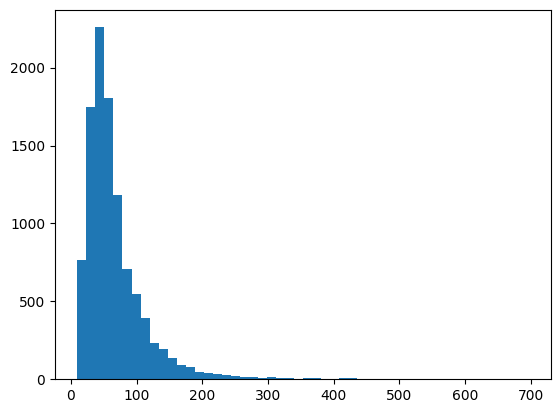

In [16]:
plt.hist(dp_components[dp_components['N_COMP']!=1]['SIGMA'].unique(), bins=50)
plt.show()

## Eyeball a fit
Overlay data, total model, and every component for one target.

plotting TARGETID 39627817930985579  N_COMP = 4


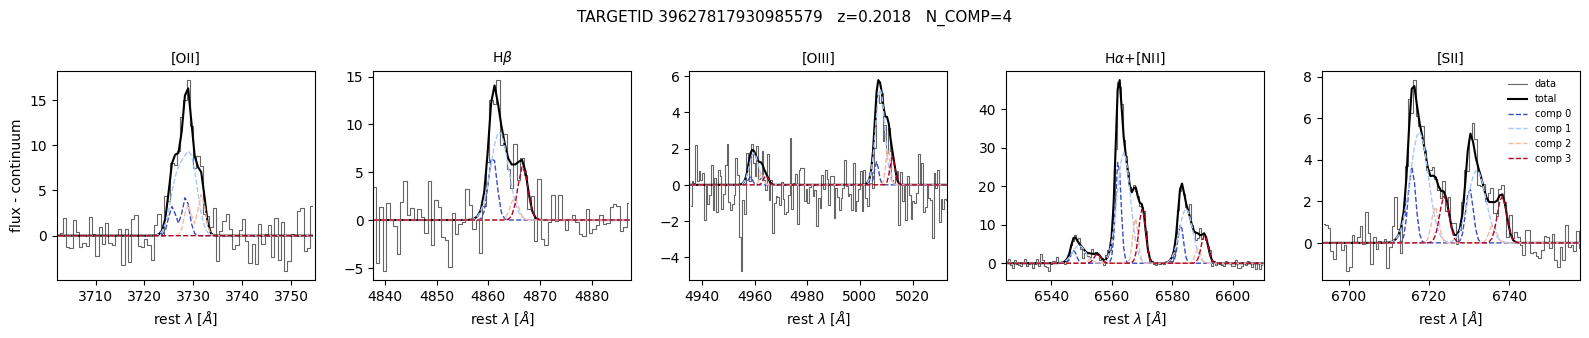

In [17]:
# prefer a multi-component target if we found one
if len(dp_sample):
    tid = int(dp_sample.sort_values('N_COMP', ascending=False)['TARGETID'].iloc[9])
else:
    tid = int(dp_parent['TARGETID'].iloc[0])
# tid = 39627793775986614
print('plotting TARGETID', tid, ' N_COMP =', int(dp_parent.loc[dp_parent['TARGETID']==tid, 'N_COMP'].iloc[0]))
fig, axes = DP.plot_fit(ALL_SPECTRA, dp_parent, dp_components, id=tid)
plt.show()

## Inspect the schema

In [18]:
print('parent columns:')
print(list(dp_parent.columns))
print()
print('component columns:')
print(list(dp_components.columns))

parent columns:
['TARGETID', 'RA', 'DEC', 'Z', 'LOGM', 'LOGSFR', 'N_COMP', 'N_COMP_FIT', 'BIC_1', 'CHISQ_1', 'BIC_2', 'CHISQ_2', 'BIC_3', 'CHISQ_3', 'BIC_4', 'CHISQ_4', 'OII3726_FLUX_TOT', 'OII3729_FLUX_TOT', 'Hbeta_FLUX_TOT', 'OIII4959_FLUX_TOT', 'OIII5007_FLUX_TOT', 'NII6548_FLUX_TOT', 'NII6583_FLUX_TOT', 'Halpha_FLUX_TOT', 'SII6716_FLUX_TOT', 'SII6731_FLUX_TOT', 'LOGSFR_FIT']

component columns:
['TARGETID', 'N_COMP', 'COMP_IDX', 'LINE', 'LAM0', 'DV', 'SIGMA', 'AMP', 'FLUX', 'FLUX_ERR', 'SNR', 'SIG', 'NOISE3', 'COMP_INSIG', 'BPT', 'OIII_HB_BOUND', 'NII_HA_BOUND']
